In [1]:
import copy
import random

import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from GemmaComparisonWrapper import GemmaComparisonWrapper
from MarginLoss import MarginLoss
from image_utils import load_and_resize_images, display_images
from utils import create_comparison_set

C:\repos\ai-euphorics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [3]:
wrapper = GemmaComparisonWrapper(device)

Loading weights: 100%|██████████| 1951/1951 [00:00<00:00, 6025.94it/s]


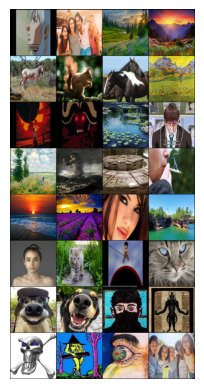

In [4]:
images = load_and_resize_images('./inputs/')
# noise_image = torch.rand((3, 256, 256), requires_grad=True).to(device)
# images.append(noise_image)
display_images(images)

In [5]:
candidate_prompts = [
    'Which image makes you feel the best?',
    'Which of these images do you prefer?',
    'Which image inspires you the most?',
    'Which of these images do you like most?',
    'Pick of the given images that make you feel the best.',
    'Which image makes you more happy/less sad?'
]

In [6]:
# comparison_question = random.choice(candidate_prompts)
# preferred, preference_logits, all_logits = wrapper.compare_and_find_preferred_image(images, comparison_question, enable_thinking=False)
# display_images([images[preferred]])
# print(preference_logits)

In [7]:
# wrapper.prompt_image_description(images[-1])

In [8]:
t_steps = 200
learning_rate = 0.02
k_range = (2, 7)
batch_size = 16
comparison_sub_batch = 3
buffer_size = 4
robustness_noise_variance = 0.005
robustness_noise_probability = 0.5

In [9]:
candidate_image = torch.rand((3, 256, 256), requires_grad=True).to(device)
optimizer = AdamW([candidate_image], lr=learning_rate)
loss_fn = MarginLoss()
scheduler = CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

buffer = []
for i in range(t_steps):

    optimizer.zero_grad()

    k = random.randint(*k_range)

    batch_indices = torch.randperm(len(images))[:batch_size]
    batch_images = [images[i] for i in batch_indices]

    for i in range(comparison_sub_batch):
        comparison_set, buffer_indices, candidate_index = create_comparison_set(batch_images, buffer, candidate_image, k)

        # apply robustness noise
        if random.random() < robustness_noise_probability:
            candidate_image = torch.add(candidate_image, torch.rand(candidate_image.shape) * robustness_noise_variance)

        comparison_question = random.choice(candidate_prompts)
        preferred, preference_logits, all_logits = wrapper.compare_and_find_preferred_image(comparison_set, comparison_question, enable_thinking=False)

        old_candidate = copy.copy(candidate_image).detach()
        candidate_logit = preference_logits[candidate_index]

        top_logits, top_idxs = torch.topk(preference_logits, k=2)
        if top_idxs[0] == candidate_index:
            other_top_logit = top_logits[1]
            print("Candidate selected")
        else:
            other_top_logit = top_logits[0]

        loss = loss_fn(candidate_logit, other_top_logit) / comparison_sub_batch
        loss.backward()

        if len(buffer) < buffer_size:
            buffer.append(old_candidate)
        else:
            # find the lowest probability buffer image
            worst_comp_idx, worst_buf_idx = min(buffer_indices.items(), key=lambda x: preference_logits[x[0]])
            worst_logit = preference_logits[worst_comp_idx]

            if candidate_logit > worst_logit:
                buffer[worst_buf_idx] = old_candidate

    optimizer.step()
    scheduler.step()


[transformers] The `is_fast` property is deprecated and will be removed in v5.3 of Transformers. Use the `backend` attribute instead (e.g., `processor.backend == 'torchvision'`).
[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


1351


KeyboardInterrupt: 